# Intelligent Skill-Gap & Resume Analyzer using Deep Learning
## Objective
This project analyzes a candidate's resume and compares it with real-world job descriptions using transformer-based sentence embeddings. It identifies missing skills, calculates resume-job similarity, evaluates communication quality, anonymizes personal information, and generates recommendations for improving employability.



## Project Overview

This project, the **Intelligent Skill-Gap & Resume Analyzer**, is a powerful tool designed to optimize the job application process for candidates. Leveraging advanced natural language processing (NLP) and transformer-based sentence embeddings, it provides comprehensive analysis of resumes against real-world job descriptions.

### Objectives:

*   **Identify Skill Gaps:** Pinpoint skills missing from a candidate's resume that are crucial for target job roles.
*   **Quantify Resume-Job Similarity:** Calculate the semantic similarity between a resume and a job description to assess compatibility.
*   **Evaluate Communication Quality:** Grade the impact and effectiveness of communication in a resume, offering actionable suggestions for improvement.
*   **Enhance Privacy:** Anonymize sensitive personal information (PII) within resumes to promote bias-blind hiring.
*   **Provide Actionable Recommendations:** Generate personalized learning recommendations to help candidates acquire missing skills and improve their employability.
*   **Calculate ATS Score:** Provide an Applicant Tracking System (ATS) compatibility score to help candidates tailor their resumes effectively.

### Key Features:

*   **Transformer-Based Semantic Matching:** Utilizes state-of-the-art `sentence-transformers` to embed resumes and job descriptions into a shared vector space, enabling accurate similarity comparison.
*   **Dynamic Skill Extraction:** Automatically identifies technical skills present in both resumes and job descriptions using a predefined list of tech skills.
*   **Skill Gap Analysis Module:** Compares extracted skills to highlight matched and missing competencies.
*   **Communication Impact Grader:** Analyzes resume text for strong action verbs, quantifiable achievements, and structural elements to provide a communication score and suggestions.
*   **Bias-Blind Resume Anonymizer:** Employs `spaCy` for Named Entity Recognition (NER) to detect and redact PII, fostering fair hiring practices.
*   **ATS Compatibility Calculator:** Aggregates semantic similarity, communication score, and skill match to generate a holistic ATS score.
*   **Personalized Learning Recommendations:** Maps missing skills to relevant online courses and learning paths.
*   **Interactive Gradio Interface:** Provides an easy-to-use web interface for users to input resume indices and instantly receive detailed analysis reports.
*   **Detailed Reporting:** Generates comprehensive reports including all analysis metrics, skill breakdowns, suggestions, and recommendations.

### 1. Install Libraries

In [49]:
!pip -q install Pillow --upgrade
!pip -q install sentence-transformers
!pip -q install transformers
!pip -q install spacy
!pip -q install gradio
!pip -q install pdfplumber
!pip -q install python-docx
!pip -q install PyMuPDF
!pip -q install nltk
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 65.6 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [52]:
print('Attempting to fix Pillow version conflict...')

Attempting to fix Pillow version conflict...


In [53]:
# Uninstall current Pillow to ensure clean installation of a compatible version
!pip uninstall -y Pillow

Found existing installation: pillow 12.3.0
Uninstalling pillow-12.3.0:
  Successfully uninstalled pillow-12.3.0


In [55]:
# Install a compatible Pillow version (e.g., < 10.0.0, as 10.0.0 can cause issues with some libraries)
!pip install 'Pillow<10.0.0'

  Using cached Pillow-9.5.0-cp312-cp312-linux_x86_64.whl
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pdfplumber 0.11.10 requires Pillow>=12.2.0, but you have pillow 9.5.0 which is incompatible.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.5.0 which is incompatible.


### 2. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import re
import string

from sklearn.metrics.pairwise import cosine_similarity

from sentence_transformers import SentenceTransformer

import spacy

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

import warnings
warnings.filterwarnings("ignore")

### 3. Load Dataset

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Resume[1].csv to Resume[1].csv


In [4]:
uploaded = files.upload()

Saving data.csv to data (2).csv


### 4. Data Preprocessing

In [11]:
import pandas as pd
resume_df = pd.read_csv('/content/Resume.csv', engine='python', sep=',', on_bad_lines='skip')
resume_df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [12]:
job_df = pd.read_csv('/content/data.csv', engine='python', sep=',', on_bad_lines='skip')
job_df.head()

,Job Title,Description
0,Data Analyst,job overview were seeking a data analyst to tu...
1,Data Reporting Analyst,about wspc wspc is a cooperative of outstandin...
2,Data Analyst (Power BI/Python),data analyst power bipython employment type fu...
3,Data & Reporting Analyst,our company pharmerica overview the data repor...
4,Data Quality Analyst (Remote Opportunity),vetsez is seeking a data quality analyst teste...


In [13]:
print(resume_df.shape)
print(job_df.shape)

(1853, 4)
(521, 2)


In [14]:
print("Resume Dataset")
display(resume_df.head())
print()
print("\nJob Description Dataset")
display(job_df.head())

Resume Dataset


,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR




Job Description Dataset


,Job Title,Description
0,Data Analyst,job overview were seeking a data analyst to tu...
1,Data Reporting Analyst,about wspc wspc is a cooperative of outstandin...
2,Data Analyst (Power BI/Python),data analyst power bipython employment type fu...
3,Data & Reporting Analyst,our company pharmerica overview the data repor...
4,Data Quality Analyst (Remote Opportunity),vetsez is seeking a data quality analyst teste...


In [15]:
print("Resume Missing Values")
print(resume_df.isnull().sum())

print()

print("Job Missing Values")
print(job_df.isnull().sum())

Resume Missing Values
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

Job Missing Values
Job Title      0
Description    0
dtype: int64


In [16]:
resume_df = resume_df.dropna()

job_df = job_df.dropna()

print(resume_df.shape)
print(job_df.shape)

(1853, 4)
(521, 2)


In [17]:
resume_df = resume_df[['Resume_str','Category']]

job_df = job_df[['Job Title','Description']]

resume_df.head()

,Resume_str,Category
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR
1,"HR SPECIALIST, US HR OPERATIONS ...",HR
2,HR DIRECTOR Summary Over 2...,HR
3,HR SPECIALIST Summary Dedica...,HR
4,HR MANAGER Skill Highlights ...,HR


In [25]:
!pip -q install nltk

In [32]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import re
import string
nltk.download('stopwords')
nltk.download('wordnet')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):

    text = text.lower()

    text = re.sub(r'http\S+', '', text)

    text = re.sub(r'\S+@\S+', '', text)

    text = re.sub(r'\d+', '', text)

    text = text.translate(str.maketrans('', '', string.punctuation))

    text = re.sub(r'\s+', ' ', text).strip()

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [33]:
resume_df["Clean_Resume"] = resume_df["Resume_str"].apply(preprocess_text)
job_df["Clean_Description"] = job_df["Description"].apply(preprocess_text)

print("Cleaning Completed Successfully!")

resume_df.head()

Cleaning Completed Successfully!


,Resume_str,Category,Clean_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,HR,hr administratormarketing associate hr adminis...
1,"HR SPECIALIST, US HR OPERATIONS ...",HR,hr specialist u hr operation summary versatile...
2,HR DIRECTOR Summary Over 2...,HR,hr director summary year experience recruiting...
3,HR SPECIALIST Summary Dedica...,HR,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,HR,hr manager skill highlight hr skill hr departm...


In [35]:
from sentence_transformers import SentenceTransformer
print("Loading Transformer Model...")

model = SentenceTransformer('all-MiniLM-L6-v2')

print("Model Loaded Successfully!")

Loading Transformer Model...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model Loaded Successfully!


In [36]:
resume_embeddings = model.encode(
    resume_df["Clean_Resume"].tolist(),
    show_progress_bar=True
)
job_embeddings = model.encode(
    job_df["Clean_Description"].tolist(),
    show_progress_bar=True
)
print("Resume Embeddings Shape :", resume_embeddings.shape)
print("Job Embeddings Shape :", job_embeddings.shape)

Batches:   0%|          | 0/58 [00:00<?, ?it/s]

Batches:   0%|          | 0/17 [00:00<?, ?it/s]

Resume Embeddings Shape : (1853, 384)
Job Embeddings Shape : (521, 384)


In [37]:
def find_best_matching_job(resume_index):

    resume_vector = resume_embeddings[resume_index].reshape(1, -1)

    similarities = cosine_similarity(
        resume_vector,
        job_embeddings
    )[0]

    best_index = np.argmax(similarities)

    return {
        "Job Title": job_df.iloc[best_index]["Job Title"],
        "Similarity Score": similarities[best_index],
        "Job Description": job_df.iloc[best_index]["Description"]
    }

In [41]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
resume_number = 0

result = find_best_matching_job(resume_number)

print("="*60)
print("Resume Category:")
print(resume_df.iloc[resume_number]["Category"])

print("\nBest Matching Job:")
print(result["Job Title"])

print("\nSimilarity Score:")
print(round(result["Similarity Score"]*100,2), "%")

print("\nJob Description Preview:\n")
print(result["Job Description"][:600])

Resume Category:
HR

Best Matching Job:
Sr Analyst Data

Similarity Score:
74.4 %

Job Description Preview:

heres why you will love it here recognition programs and rewards excellent health care options, including medical, dental, and vision a peoplefirst culture go hilton travel discounts program hilton hotel rates worldwide. perks at work employee pricing platform employee assistance program that supports your physical and mental wellbeing. paid vacation time and paid sick days 401k program with company match tuition reimbursement programs numerous learning and advancement opportunities and more essential job functions design, develop, and present accurate and relevant reporting and analysis to va


### 5. Visualize Similarity

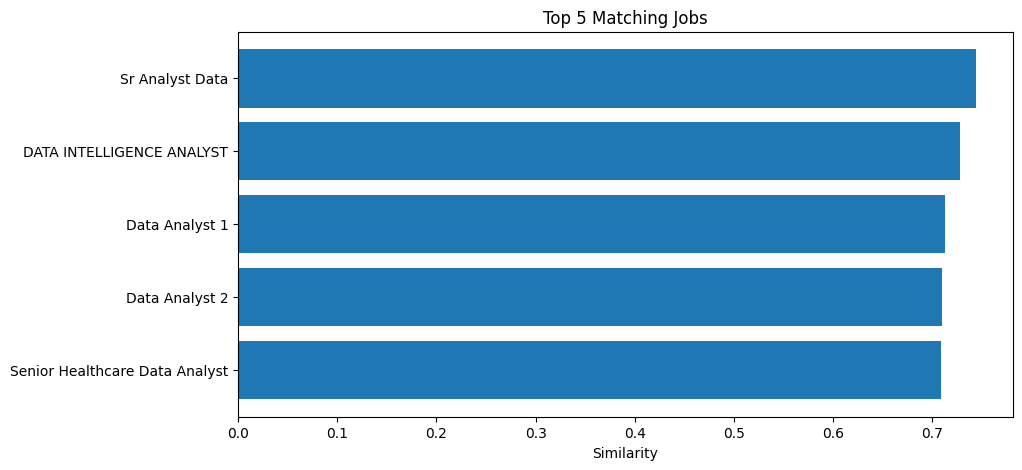

In [43]:
import matplotlib.pyplot as plt
scores = cosine_similarity(
    resume_embeddings[0].reshape(1,-1),
    job_embeddings
)[0]

top5 = np.argsort(scores)[-5:]

titles = job_df.iloc[top5]["Job Title"]

values = scores[top5]

plt.figure(figsize=(10,5))

plt.barh(titles, values)

plt.xlabel("Similarity")

plt.title("Top 5 Matching Jobs")

plt.show()

In [49]:
TECH_SKILLS = [
    "python", "java", "c", "c++", "sql", "mysql", "postgresql",
    "mongodb", "html", "css", "javascript", "react", "angular",
    "node", "express", "flask", "django", "fastapi",
    "machine learning", "deep learning", "tensorflow",
    "pytorch", "keras", "opencv", "nlp",
    "pandas", "numpy", "matplotlib", "seaborn",
    "scikit-learn", "docker", "kubernetes",
    "aws", "azure", "gcp",
    "git", "github",
    "linux", "rest api", "api",
    "data analysis", "power bi", "excel"
]

In [50]:
def extract_skills(text):

    text = text.lower()

    found_skills = []

    for skill in TECH_SKILLS:
        if skill.lower() in text:
            found_skills.append(skill)

    return sorted(list(set(found_skills)))

### 6. Skill Gap Analysis

In [76]:
def skill_gap_analysis(resume_index):

    result = find_best_matching_job(resume_index)

    resume_text = resume_df.iloc[resume_index]["Clean_Resume"]

    job_text = preprocess_text(result["Job Description"])

    resume_skills = extract_skills(resume_text)

    job_skills = extract_skills(job_text)

    matched = list(set(resume_skills) & set(job_skills))

    missing = list(set(job_skills) - set(resume_skills))

    return {

        "Matched Skills": sorted(matched),

        "Missing Skills": sorted(missing),

        "Resume Skills": sorted(resume_skills),

        "Job Skills": sorted(job_skills),

        "Similarity": result["Similarity Score"]

    }

In [77]:
analysis = skill_gap_analysis(0)

print("="*60)

print("Resume Skills")

print(analysis["Resume Skills"])

print()

print("="*60)

print("Job Skills")

print(analysis["Job Skills"])

print()

print("="*60)

print("Matched Skills")

print(analysis["Matched Skills"])

print()

print("="*60)

print("Missing Skills")

print(analysis["Missing Skills"])

Resume Skills
['c', 'data analysis']

Job Skills
['c', 'excel', 'power bi', 'sql']

Matched Skills
['c']

Missing Skills
['excel', 'power bi', 'sql']


### 7. Communication Impact Grader

In [53]:
ACTION_VERBS = [

"developed","designed","implemented","created","built",

"engineered","optimized","managed","led","improved",

"reduced","increased","automated","analyzed","deployed",

"architected","maintained","tested","trained","integrated"

]

def communication_score(text):

    text = text.lower()

    score = 0

    suggestions = []


    verbs = sum(1 for verb in ACTION_VERBS if verb in text)

    score += min(verbs*5,40)


    numbers = len(re.findall(r"\d+", text))

    score += min(numbers*5,20)

    words = len(text.split())

    if words > 150:

        score += 20

    elif words > 80:

        score += 15

    elif words > 40:

        score += 10

    # Sections

    sections = [

        "experience",

        "education",

        "project",

        "skill"

    ]

    section_count = sum(1 for s in sections if s in text)

    score += section_count*5

    if verbs < 5:

        suggestions.append("Use more strong action verbs.")

    if numbers < 3:

        suggestions.append("Add quantified achievements.")

    if words < 100:

        suggestions.append("Include more project details.")

    score = min(score,100)

    return score, suggestions

In [54]:
score, suggestions = communication_score(

    resume_df.iloc[0]["Resume_str"]

)

print("Communication Score :",score,"%")

print()

print("Suggestions")

for s in suggestions:

    print("-",s)

Communication Score : 90 %

Suggestions


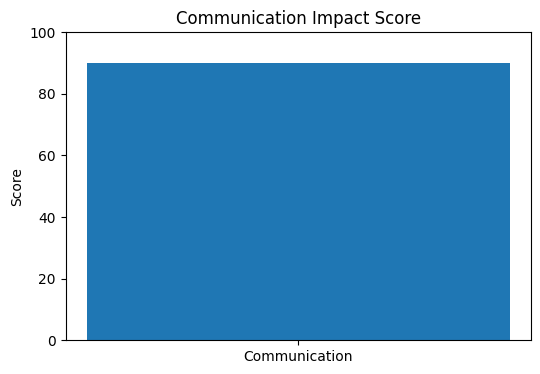

In [55]:
plt.figure(figsize=(6,4))

plt.bar(

["Communication"],

[score]

)

plt.ylim(0,100)

plt.ylabel("Score")

plt.title("Communication Impact Score")

plt.show()

In [56]:
import spacy

nlp = spacy.load("en_core_web_sm")

print("spaCy model loaded successfully!")

spaCy model loaded successfully!


### 8. Bias-Blind Resume

In [57]:
PII_LABELS = [
    "PERSON",
    "ORG",
    "GPE",
    "LOC",
    "DATE",
    "EMAIL",
    "PHONE"
]

def anonymize_resume(text):

    doc = nlp(text)

    anonymized = text

    for ent in reversed(doc.ents):

        if ent.label_ in PII_LABELS:

            anonymized = (
                anonymized[:ent.start_char]
                + f"[{ent.label_}]"
                + anonymized[ent.end_char:]
            )

    return anonymized

In [58]:
sample_resume = resume_df.iloc[0]["Resume_str"]

clean_resume = anonymize_resume(sample_resume)

print(clean_resume[:2000])

         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with [DATE] of experience in [GPE] and Customer Service Management.   Respected builder and leader of customer-focused teams; strives to instill a shared, enthusiastic commitment to customer service.         Highlights         Focused on customer satisfaction  [ORG] management  Marketing savvy  Conflict resolution techniques     Training and development  Skilled multi-tasker  Client relations specialist           Accomplishments      [GPE] [ORG] Supervisor Training Certification  Certified by [ORG] in [ORG] by Segment   [GPE] Worldwide General Manager [PERSON]  Accomplished Trainer for cross server hospitality systems such as    Hilton OnQ  ,   Micros    Opera PMS   , [PERSON]OPERA    Reservation System (ORS) ,   Holidex    Completed courses and seminars in customer service, sales strategies, inventory control, loss prevention, safety, time management, leadership and per

### 9. ATS Score

In [59]:
def calculate_ats_score(resume_index):

    analysis = skill_gap_analysis(resume_index)

    communication, _ = communication_score(
        resume_df.iloc[resume_index]["Resume_str"]
    )

    similarity = analysis["Similarity"] * 100

    matched = len(analysis["Matched Skills"])
    missing = len(analysis["Missing Skills"])

    if matched + missing == 0:
        skill_score = 50
    else:
        skill_score = (matched / (matched + missing)) * 100

    ats = (
        0.40 * similarity +
        0.30 * communication +
        0.30 * skill_score
    )

    return round(ats,2)

In [60]:
ats = calculate_ats_score(0)

print("ATS Score :", ats,"%")

ATS Score : 64.26 %


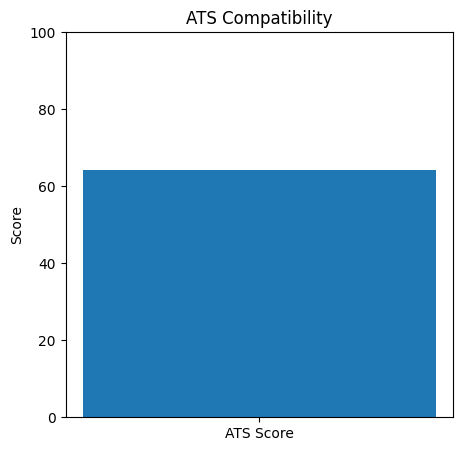

In [61]:
plt.figure(figsize=(5,5))

plt.bar(
    ["ATS Score"],
    [ats]
)

plt.ylim(0,100)

plt.ylabel("Score")

plt.title("ATS Compatibility")

plt.show()

### 10. Recommendation Engine

In [62]:
COURSE_MAP = {

    "docker":"Learn Docker Fundamentals",

    "aws":"AWS Cloud Practitioner",

    "kubernetes":"Kubernetes Basics",

    "tensorflow":"Deep Learning with TensorFlow",

    "pytorch":"PyTorch for Beginners",

    "react":"React.js Complete Course",

    "django":"Build Web Apps using Django",

    "flask":"Flask Web Development",

    "sql":"Advanced SQL",

    "git":"Git & GitHub",

    "github":"Git & GitHub",

    "machine learning":"Machine Learning Specialization",

    "deep learning":"Deep Learning Specialization",

    "nlp":"Natural Language Processing",

    "power bi":"Microsoft Power BI",

    "excel":"Advanced Excel"
}

def learning_recommendations(missing_skills):

    recommendations = []

    for skill in missing_skills:

        if skill in COURSE_MAP:

            recommendations.append(

                COURSE_MAP[skill]

            )

    return recommendations

In [63]:
analysis = skill_gap_analysis(0)

recommendations = learning_recommendations(
    analysis["Missing Skills"]
)

print("Recommended Learning Path\n")

for course in recommendations:

    print("•", course)

Recommended Learning Path

• Advanced Excel
• Microsoft Power BI
• Advanced SQL


### 11. Final Report

In [64]:
def generate_final_report(resume_index):

    result = find_best_matching_job(resume_index)

    analysis = skill_gap_analysis(resume_index)

    communication, suggestions = communication_score(
        resume_df.iloc[resume_index]["Resume_str"]
    )

    ats = calculate_ats_score(resume_index)

    recommendations = learning_recommendations(
        analysis["Missing Skills"]
    )

    report = {
        "Resume Category": resume_df.iloc[resume_index]["Category"],
        "Best Matching Job": result["Job Title"],
        "Semantic Similarity (%)": round(result["Similarity Score"] * 100, 2),
        "ATS Score (%)": ats,
        "Communication Score (%)": communication,
        "Resume Skills": analysis["Resume Skills"],
        "Matched Skills": analysis["Matched Skills"],
        "Missing Skills": analysis["Missing Skills"],
        "Communication Suggestions": suggestions,
        "Learning Recommendations": recommendations
    }

    return report

In [65]:
report = generate_final_report(0)

print("=" * 70)
print("INTELLIGENT SKILL-GAP & RESUME ANALYSIS REPORT")
print("=" * 70)

for key, value in report.items():
    print(f"\n{key}")
    print(value)

INTELLIGENT SKILL-GAP & RESUME ANALYSIS REPORT

Resume Category
HR

Best Matching Job
Sr Analyst Data

Semantic Similarity (%)
74.4

ATS Score (%)
64.26

Communication Score (%)
90

Resume Skills
['c', 'data analysis']

Matched Skills
['c']

Missing Skills
['excel', 'power bi', 'sql']

Communication Suggestions
[]

Learning Recommendations
['Advanced Excel', 'Microsoft Power BI', 'Advanced SQL']


### 12. Visualizations

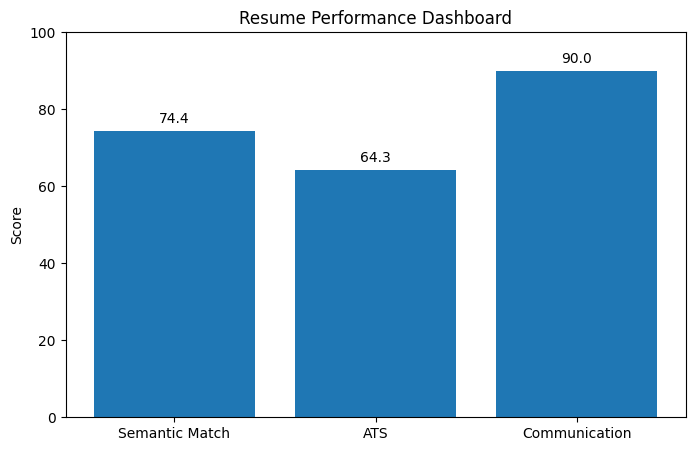

In [66]:
scores = {
    "Semantic Match": report["Semantic Similarity (%)"],
    "ATS": report["ATS Score (%)"],
    "Communication": report["Communication Score (%)"]
}

plt.figure(figsize=(8,5))

plt.bar(scores.keys(), scores.values())

plt.ylim(0,100)

plt.ylabel("Score")

plt.title("Resume Performance Dashboard")

for i, value in enumerate(scores.values()):
    plt.text(i, value + 2, f"{value:.1f}", ha='center')

plt.show()

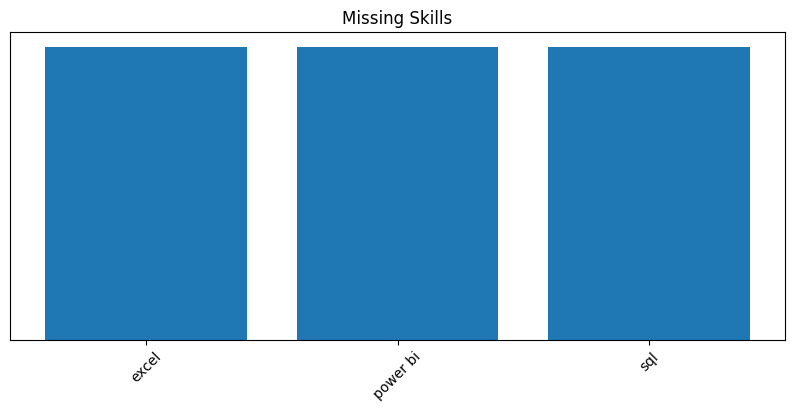

In [67]:
missing = report["Missing Skills"]

if len(missing) > 0:

    plt.figure(figsize=(10,4))

    plt.bar(missing, [1]*len(missing))

    plt.title("Missing Skills")

    plt.xticks(rotation=45)

    plt.yticks([])

    plt.show()

else:

    print("No Missing Skills Found!")

In [68]:
resume_number = int(input("Enter Resume Index: "))

report = generate_final_report(resume_number)

print("\n")

print("=" * 70)

print("AI RESUME REPORT")

print("=" * 70)

for key, value in report.items():

    print(f"\n{key}")

    print(value)

Enter Resume Index: 90


AI RESUME REPORT

Resume Category
HR

Best Matching Job
Human Resources Data Analyst

Semantic Similarity (%)
82.56

ATS Score (%)
85.52

Communication Score (%)
75

Resume Skills
['c', 'excel']

Matched Skills
['c', 'excel']

Missing Skills
[]

Communication Suggestions
['Use more strong action verbs.']

Learning Recommendations
[]


### 13. Gradio Interface

In [69]:
import gradio as gr

def analyze_resume(index):

    try:
        index = int(index)

        report = generate_final_report(index)

        output = ""

        for key, value in report.items():
            output += f"{key}\n{value}\n\n"

        return output

    except Exception as e:
        return str(e)

demo = gr.Interface(
    fn=analyze_resume,
    inputs=gr.Number(label="Resume Index"),
    outputs=gr.Textbox(label="Analysis Report", lines=25),
    title="Intelligent Skill-Gap & Resume Analyzer",
    description="Analyze a resume from the dataset using transformer-based semantic matching."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c69cbf73f92458fdc3.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [71]:
import json
import numpy as np

# Convert numpy.float32 values to standard floats for JSON serialization
serializable_report = {}
for key, value in report.items():
    if isinstance(value, np.float32):
        serializable_report[key] = float(value)
    elif isinstance(value, list) and all(isinstance(item, np.float32) for item in value):
        serializable_report[key] = [float(item) for item in value]
    else:
        serializable_report[key] = value

with open("resume_analysis_report.json", "w") as f:
    json.dump(serializable_report, f, indent=4)

print("Report saved successfully!")

Report saved successfully!
